In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
cluster_ref = run["clusters"]
marker_ref = run["markers"]
cluster_values = np.asarray(run.cells.fetch("clusters"))
pd.Series(cluster_values).value_counts().sort_index()

1      694
2       28
3      237
4     1004
5      317
6      539
7      142
8      263
9      378
10     311
11      15
12      12
Name: count, dtype: int64

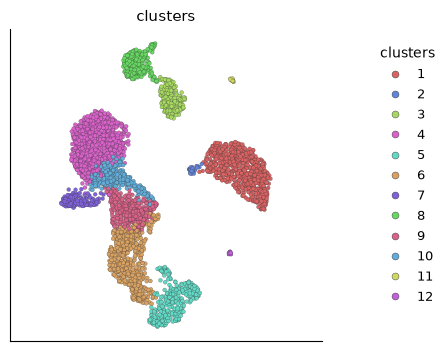

In [2]:
ds.plots.embedding(run=run, layout="umap", color_by="clusters")

In [3]:
group_id = pd.Series(cluster_values).value_counts().index[0]
group_markers = ds.get_markers(
    marker=marker_ref,
    group_id=group_id,
    min_score=-1,
    min_frac_exp=-1,
)
group_markers[
    [
        "feature_name",
        "score",
        "frac_exp",
        "fold_change",
        "auc",
        "p_value",
        "p_value_adjusted",
    ]
].head(10)

,feature_name,score,frac_exp,fold_change,auc,p_value,p_value_adjusted
0,ADTRP,0.41057,0.24203,7.01255,0.60208,2.122675e-83,3.727239e-81
1,FHIT,0.34388,0.62251,6.12971,0.75649,1.297768e-216,1.554448e-213
2,ANKRD55,0.33443,0.14044,6.21225,0.55836,2.183907e-45,1.441808e-43
3,TSHZ2,0.31510,0.32072,3.96487,0.62291,4.188060e-84,7.471232e-82
4,AL031280.1,0.31406,0.16335,4.60520,0.56289,8.361570e-41,4.604767e-39
5,CMTM8,0.31237,0.30578,3.71605,0.61065,2.354141e-65,2.892058e-63
6,EPHX2,0.31103,0.38745,4.61110,0.64836,3.218353e-101,7.709795e-99
7,AC009041.2,0.31035,0.14741,5.86866,0.56065,6.169623e-46,4.154956e-44
8,LRRN3,0.30605,0.53785,5.81899,0.72201,1.099399e-191,9.703067e-189
9,CHRM3-AS2,0.30605,0.36952,4.24173,0.64164,3.369847e-97,7.435389e-95


In [4]:
markers = ds.get_markers(
    marker=marker_ref,
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)
panel_hits = (
    markers[markers["feature_name"].astype(str).isin(["CD14", "MS4A1", "CD3D"])]
    .sort_values(["feature_name", "score"], ascending=[True, False])
    .groupby("feature_name", as_index=False)
    .head(1)[["feature_name", "group_id", "score", "auc", "frac_exp"]]
)
panel_hits

,feature_name,group_id,score,auc,frac_exp
2,CD14,1,0.90389,0.98481,0.97118
268412,CD3D,6,0.21106,0.76253,0.98145
335405,MS4A1,8,0.48929,0.96317,0.98859


In [5]:
unique = sorted(pd.unique(cluster_values), key=str)
label_map = {str(value): f"Cluster {value}" for value in unique}
for gene, name in (
    ("CD14", "Monocytes"),
    ("MS4A1", "B cells"),
    ("CD3D", "T cells"),
):
    hit = panel_hits.loc[panel_hits["feature_name"].astype(str) == gene]
    if not hit.empty:
        label_map[str(hit.iloc[0]["group_id"])] = name

cell_type = np.asarray([label_map[str(value)] for value in cluster_values], dtype=object)
ds.cells.insert("cell_type", cell_type, key="I", overwrite=True)
pd.Series(cell_type).value_counts()

Cluster 4     1004
Monocytes      694
T cells        539
Cluster 9      378
Cluster 5      317
Cluster 10     311
B cells        263
Cluster 3      237
Cluster 7      142
Cluster 2       28
Cluster 11      15
Cluster 12      12
Name: count, dtype: int64

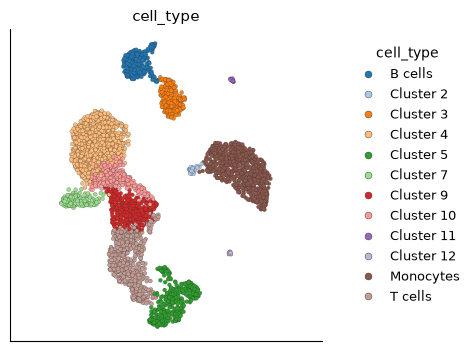

In [6]:
ds.plots.embedding(
    layout=run["umap"],
    color_by="cell_type",
)

In [7]:
fine_clusters = ds.run_leiden_clustering(
    run["connectivity_map"],
    resolution=1.5,
)
smart_labels = ds.smart_label(fine_clusters, cluster_ref)
smart_values = np.asarray(ds.load_artifact(smart_labels)["values"][:])
pd.crosstab(
    pd.Series(np.asarray(ds.load_artifact(fine_clusters)["values"][:]), name="fine"),
    pd.Series(smart_values, name="smart label"),
)

smart label,10a,11a,12a,1a,1b,2a,3a,4a,4b,4c,...,5a,5b,5c,6a,6b,6c,7a,8a,9a,9b
fine,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,381,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,317,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,24,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,248,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,376,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,148,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,30,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,139,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,153,0,0,0,0
